Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=90, salida=1
  X_train: (14490, 90, 23) | y_train: (14490, 23)
  X_test:  (1611, 90, 23)  | y_test:  (1611, 23)

  Modelo: CNN_f64_k5_in90_out1_MP_GAP
  Parámetros: 945,239


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_72 (Conv1D)              │ (None, 90, 64)         │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_73 (Conv1D)              │ (None, 45, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_74 (Conv1D)              │ (None, 45, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_75 (Conv1D)              │ (None, 45, 512)        │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_33     │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 945,239 (3.61 MB)

 Trainable params: 945,239 (3.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0745 - val_loss: 0.0714
Epoch 2/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0738 - val_loss: 0.0706
Epoch 3/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0731 - val_loss: 0.0699
Epoch 4/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0723 - val_loss: 0.0692
Epoch 5/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0716 - val_loss: 0.0684
Epoch 6/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0709 - val_loss: 0.0677
Epoch 7/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0702 - val_loss: 0.0670
Epoch 8/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0695 - val_loss: 0.0663
Epoch 9/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0688 - val_loss: 0.0656
Epoch 10/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0681 - val_loss: 0.0649
Epoch 11/500
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0674 - val_loss: 0.0642
Epoch 12/500
204/204 ━━━━━━━━━

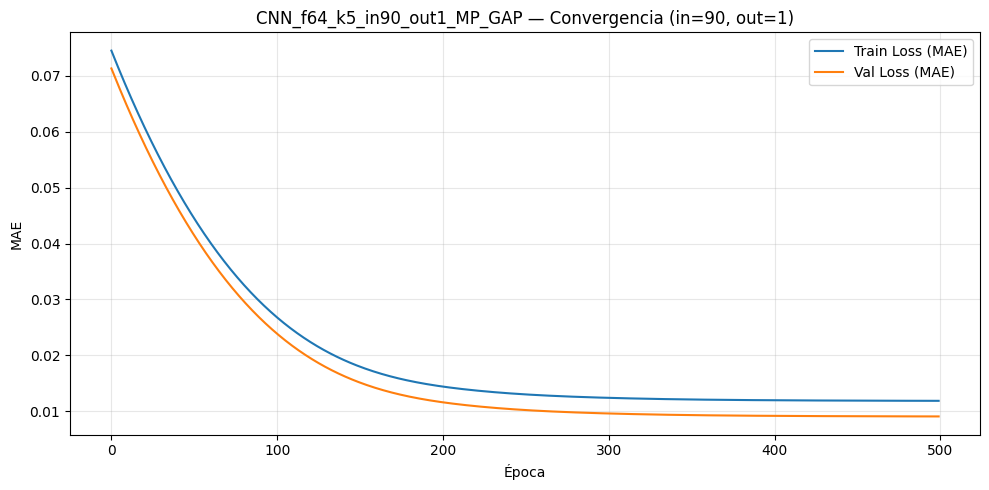

Modelo guardado en: models/CNN_f64_k5_in90_out1_MP_GAP.keras


In [34]:
"""
cnn_model_single.py — Entrenamiento de CNN para UNA combinación de ventanas
=============================================================================

Cambia los parámetros en la sección CONFIGURACIÓN y ejecuta.
"""
import os
import sys
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Apuntar a la raíz del repositorio
os.chdir(r'C:\Users\eneko\neural-network-forecasting')
sys.path.insert(0, os.getcwd())

# Imports del repositorio
from config import RANDOM_SEED, MODELS_DIR, FIGURES_DIR
from src.data_pipeline import load_data, get_train_test
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves

np.random.seed(RANDOM_SEED)
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
from tensorflow.keras.layers import SpatialDropout1D

# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

INPUT_WINDOW = 90          
OUTPUT_WINDOW = 1        
FILTERS = 64              
KERNEL_SIZE = 5           
PADDING = 'same'          
POOL_SIZE = 2             
FILTERS_2 = 128            
KERNEL_SIZE_2 = 5         
FILTERS_3 = 256             
KERNEL_SIZE_3 = 5
FILTERS_4 = 512           
KERNEL_SIZE_4 = 5         
USE_GAP = True            
DENSE_1 = 128              
DENSE_2 = 64             
DENSE_3 = 32              
DROPOUT_RATE_1 = 0.0      
DROPOUT_RATE_2 = 0.0      
DROPOUT_RATE_3 = 0.0      
L2_REG = 0.0001           
LEARNING_RATE = 0.000001
EPOCHS = 500
BATCH_SIZE = 64
SPATIAL_DROPOUT = 0.0
VALIDATION_SPLIT = 0.1
MODEL_NAME = (f"CNN_f{FILTERS}_k{KERNEL_SIZE}_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
              f"{'_MP' if USE_MAXPOOL else ''}"
              f"{'_GAP' if USE_GAP else ''}")


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn(input_window, n_features=23):
    layers = [
        Conv1D(FILTERS, kernel_size=KERNEL_SIZE, activation='relu',
               input_shape=(input_window, n_features), padding=PADDING,
               kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None),
    ]
    if SPATIAL_DROPOUT > 0:
        layers.append(SpatialDropout1D(SPATIAL_DROPOUT))

    if USE_MAXPOOL:
        layers.append(MaxPooling1D(pool_size=POOL_SIZE))

    if FILTERS_2 > 0:
        layers.append(Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, activation='relu',
                             padding='same',
                             kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None))
        if SPATIAL_DROPOUT > 0:
            layers.append(SpatialDropout1D(SPATIAL_DROPOUT))

    if FILTERS_3 > 0:
        layers.append(Conv1D(FILTERS_3, kernel_size=KERNEL_SIZE_3, activation='relu',
                             padding='same',
                             kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None))
        if SPATIAL_DROPOUT > 0:
            layers.append(SpatialDropout1D(SPATIAL_DROPOUT))
    
    if FILTERS_4 > 0:
        layers.append(Conv1D(FILTERS_4, kernel_size=KERNEL_SIZE_4, activation='relu',
                             padding='same',
                             kernel_regularizer=l2(L2_REG) if L2_REG > 0 else None))
        if SPATIAL_DROPOUT > 0:
            layers.append(SpatialDropout1D(SPATIAL_DROPOUT))

    layers.append(GlobalAveragePooling1D() if USE_GAP else Flatten())

    layers.append(Dense(DENSE_1, activation='relu'))
    if DROPOUT_RATE_1 > 0:
        layers.append(Dropout(DROPOUT_RATE_1))

    if DENSE_2 > 0:
        layers.append(Dense(DENSE_2, activation='relu'))
        if DROPOUT_RATE_2 > 0:
            layers.append(Dropout(DROPOUT_RATE_2))

    if DENSE_3 > 0:
        layers.append(Dense(DENSE_3, activation='relu'))
        if DROPOUT_RATE_3 > 0:
            layers.append(Dropout(DROPOUT_RATE_3))

    layers.append(Dense(n_features))

    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mae')
    return model


# ============================================================================
# ENTRENAMIENTO
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

model = build_cnn(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    shuffle=True,
    verbose=1
)


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test = model.predict(X_test, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_test = compute_mae(y_test, y_pred_test)
mae_val = min(history.history['val_loss']) if 'val_loss' in history.history else None

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train: {mae_train:.6f}")
if mae_val:
    print(f"    MAE Val:   {mae_val:.6f}")
print(f"    MAE Test:  {mae_test:.6f}")
print(f"{'='*60}")

save_results(
    model_name=MODEL_NAME,
    model_type='convolutional',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model.save(os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras"))
print(f"Modelo guardado en: {MODELS_DIR}{MODEL_NAME}.keras")

In [17]:
"""
run_baselines.py — Calcula el MAE de los baselines (Buy & Hold, Naive, Zero)
"""

import os
import pandas as pd

from src.data_pipeline import load_data
from src.baselines import evaluate_all_baselines
from src.evaluation import load_all_results
from config import TABLES_DIR

# --------------------------------------------------------------------
# 1. (Opcional) Borrar el CSV previo para no acumular duplicados
# --------------------------------------------------------------------
RESET_CSV = True

# La versión antigua de evaluation.py usa un único all_results.csv.
# La versión nueva usa un CSV por tipo (baseline_results.csv, etc.).
# Borramos ambos por si acaso.
for fname in ['all_results.csv', 'baseline_results.csv']:
    fpath = os.path.join(TABLES_DIR, fname)
    if RESET_CSV and os.path.exists(fpath):
        os.remove(fpath)
        print(f"CSV previo eliminado: {fpath}")

# --------------------------------------------------------------------
# 2. Cargar log-returns
# --------------------------------------------------------------------
returns = load_data()

# --------------------------------------------------------------------
# 3. Evaluar los tres baselines en las 16 combinaciones
# --------------------------------------------------------------------
evaluate_all_baselines(returns)

# --------------------------------------------------------------------
# 4. Resumen comparativo
# --------------------------------------------------------------------
df = load_all_results()
df = df[df['model_type'] == 'baseline'].copy()

pivot_test = df.pivot_table(
    index=['input_window', 'output_window'],
    columns='model_name',
    values='mae_test'
).round(6)

pivot_train = df.pivot_table(
    index=['input_window', 'output_window'],
    columns='model_name',
    values='mae_train'
).round(6)

print("\n" + "=" * 70)
print("MAE en TEST por combinación de ventanas")
print("=" * 70)
print(pivot_test)

print("\n" + "=" * 70)
print("MAE en TRAIN por combinación de ventanas")
print("=" * 70)
print(pivot_train)

best_per_combo = (
    df.loc[df.groupby(['input_window', 'output_window'])['mae_test'].idxmin()]
      [['input_window', 'output_window', 'model_name', 'mae_test']]
      .sort_values(['input_window', 'output_window'])
      .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Mejor baseline por combinación (suelo a batir por la red neuronal)")
print("=" * 70)
print(best_per_combo.to_string(index=False))

CSV previo eliminado: results/tables/all_results.csv


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16200 días, 23 activos
Rango: 1962-01-03 → 2026-05-15
Evaluando baselines para todas las combinaciones de ventanas...
Ventana entrada=5, salida=1
  X_train: (14575, 5, 23) | y_train: (14575, 23)
  X_test:  (1620, 5, 23)  | y_test:  (1620, 23)
Resultados guardados: Buy_and_Hold | in=5 out=1 | MAE test=0.012284
Resultados guardados: Naive_LastValue | in=5 out=1 | MAE test=0.017847
Resultados guardados: Zero_Prediction | in=5 out=1 | MAE test=0.012296
Ventana entrada=5, salida=5
  X_train: (14571, 5, 23) | y_train: (14571, 23)
  X_test:  (1620, 5, 23)  | y_test:  (1620, 23)
Resultados guardados: Buy_and_Hold | in=5 out=5 | MAE test=0.005599
Resultados guardados: Naive_LastValue | in=5 out=5 | MAE test=0.013704
Resultados guardados: Zero_Prediction | in=5 out=5 | MAE test=0.005620
Ventana entrada=5, salida=30
  X_train: (14549, 5, 23) | y_train: (14549, 23)
  X_test:  (1617, 5, 23)  | y_test:  (1617, 23)
Resultados guardados: Buy_and_Hold | in=5 out=30 | MAE test=0.002322
R